# Grouped Syllable Analysis

This notebook helps you decide how to simplify the Keypoint MoSeq syllables.

It will:

- rank syllables by occupancy
- keep syllables covering a chosen cumulative fraction of frames
- label the rest as `other`
- optionally map rare syllables to the most similar kept syllable using transition-profile similarity
- rerun transition and bout-level summaries on grouped syllables


In [116]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_context("talk")
sns.set_style("whitegrid")

## Paths

In [117]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Keypoint_moseq_analysis":
    ANALYSIS_DIR = PROJECT_ROOT
    REPO_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "Keypoint_moseq_analysis").exists():
    REPO_ROOT = PROJECT_ROOT
    ANALYSIS_DIR = PROJECT_ROOT / "Keypoint_moseq_analysis"
else:
    ANALYSIS_DIR = PROJECT_ROOT
    REPO_ROOT = PROJECT_ROOT.parent

POSE_TRACKING_DIR = REPO_ROOT / "Pose_Tracking"

project_dir = ANALYSIS_DIR / "keypoint_moseq_project_home_cage"
model_name = "2026_05_13-23_29_52"

syllable_frames_path = project_dir / model_name / "syllable_frames_merged.csv"
# syllable_frames_path = project_dir / model_name / "syllable_frames.csv"

behavior_csv_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\csvs")
da_path = POSE_TRACKING_DIR / "HC_automated_social_behaviors.csv"

syllable_frames_path

WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Keypoint_moseq_analysis/keypoint_moseq_project_home_cage/2026_05_13-23_29_52/syllable_frames_merged.csv')

## Load Subject-Only Data

By default this notebook uses only subject recordings, since that is your current focus.

In [118]:
df = pd.read_csv(syllable_frames_path)
df = df[df["track_name"] == "subject"].copy()
df = df.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)
df.head()

,recording_name,frame_index,syllable,time_s,centroid_x,centroid_y,heading,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_subject,0,1,0.0,479.999302,179.382026,3.060036,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN
1,n5_subject,1,1,0.1,478.388671,185.510468,2.640279,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN
2,n5_subject,2,1,0.2,482.615886,178.666205,2.967980,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN
3,n5_subject,3,1,0.3,483.243912,178.498985,2.961226,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN
4,n5_subject,4,1,0.4,482.484321,177.155721,2.979535,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN


## Settings

In [119]:
cumulative_threshold = 0.95
apply_grouping = False
use_similarity_mapping = False

BOUT_DEFINITIONS = [
    {"prefix": "Short_Term", "introduced": "Short_Term_Introduced", "removed": "Short_Term_Removed"},
    {"prefix": "Long_Term",  "introduced": "Long_Term_Introduced",  "removed": "Long_Term_Removed"},
    {"prefix": "Novel",      "introduced": "Novel_Introduced",      "removed": "Novel_Removed"},
]

## Helpers

In [120]:
def compute_occupancy_table(df, syllable_col="syllable"):
    occ = (
        df.groupby(syllable_col)
        .size()
        .reset_index(name="n_frames")
        .sort_values("n_frames", ascending=False)
        .reset_index(drop=True)
    )
    occ["prop"] = occ["n_frames"] / occ["n_frames"].sum()
    occ["cum_prop"] = occ["prop"].cumsum()
    return occ


def select_kept_syllables(occupancy_df, threshold=0.90):
    keep_mask = occupancy_df["cum_prop"] <= threshold
    if not keep_mask.all() and keep_mask.sum() < len(occupancy_df):
        keep_mask.iloc[keep_mask.sum()] = True
    kept = occupancy_df.loc[keep_mask, "syllable"].tolist()
    return kept


def add_other_group(df, kept_syllables, source_col="syllable", out_col="syllable_grouped"):
    out = df.copy()
    out[out_col] = out[source_col].where(out[source_col].isin(kept_syllables), "other")
    return out


def extract_transitions(df, syllable_col="syllable"):
    rows = []
    for recording_name, rec in df.groupby("recording_name", sort=False):
        rec = rec.sort_values("frame_index").reset_index(drop=True)
        if len(rec) < 2:
            continue
        prev = rec.iloc[:-1].reset_index(drop=True)
        curr = rec.iloc[1:].reset_index(drop=True)
        consecutive = (curr["frame_index"].to_numpy() - prev["frame_index"].to_numpy()) == 1
        if not consecutive.any():
            continue
        part = pd.DataFrame({
            "recording_name": recording_name,
            "subject_name": prev.loc[consecutive, "subject_name"].to_numpy(),
            "time_s": curr.loc[consecutive, "time_s"].to_numpy(),
            "from_state": prev.loc[consecutive, syllable_col].to_numpy(),
            "to_state": curr.loc[consecutive, syllable_col].to_numpy(),
        })
        part["changed"] = part["from_state"] != part["to_state"]
        part["transition_label"] = part["from_state"].astype(str) + "->" + part["to_state"].astype(str)
        rows.append(part)
    if not rows:
        return pd.DataFrame(columns=["recording_name", "subject_name", "time_s", "from_state", "to_state", "changed", "transition_label"])
    return pd.concat(rows, ignore_index=True)


def build_transition_matrix(transitions_df, from_col="from_state", to_col="to_state", normalize=True):
    mat = pd.crosstab(transitions_df[from_col], transitions_df[to_col])
    mat = mat.sort_index().sort_index(axis=1)
    if normalize:
        mat = mat.div(mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return mat


def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return np.nan
    return float(np.dot(a, b) / denom)


def build_transition_profiles(df, syllable_col="syllable"):
    tr = extract_transitions(df, syllable_col=syllable_col)
    all_states = sorted(df[syllable_col].dropna().unique())
    out_mat = pd.crosstab(tr["from_state"], tr["to_state"]).reindex(index=all_states, columns=all_states, fill_value=0)
    in_mat = pd.crosstab(tr["to_state"], tr["from_state"]).reindex(index=all_states, columns=all_states, fill_value=0)

    out_prob = out_mat.div(out_mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    in_prob = in_mat.div(in_mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    profiles = {}
    for s in all_states:
        profiles[s] = np.concatenate([out_prob.loc[s].to_numpy(), in_prob.loc[s].to_numpy()])
    return profiles


def map_rare_to_kept_by_similarity(df, kept_syllables, syllable_col="syllable"):
    profiles = build_transition_profiles(df, syllable_col=syllable_col)
    rare_syllables = [s for s in sorted(df[syllable_col].unique()) if s not in kept_syllables]
    rows = []
    mapping = {}
    for rare in rare_syllables:
        best_keep = None
        best_sim = -np.inf
        for keep in kept_syllables:
            sim = cosine_similarity(profiles[rare], profiles[keep])
            if np.isnan(sim):
                continue
            if sim > best_sim:
                best_sim = sim
                best_keep = keep
        mapping[rare] = best_keep
        rows.append({"rare_syllable": rare, "mapped_to": best_keep, "similarity": best_sim})
    return mapping, pd.DataFrame(rows).sort_values(["mapped_to", "similarity"], ascending=[True, False])


def apply_similarity_mapping(df, kept_syllables, mapping, source_col="syllable", out_col="syllable_grouped_mapped"):
    out = df.copy()
    out[out_col] = out[source_col]
    mask = ~out[source_col].isin(kept_syllables)
    out.loc[mask, out_col] = out.loc[mask, source_col].map(mapping)
    return out


def match_behavior_csv(subject_name, csv_dir):
    candidates = sorted(csv_dir.glob(f"{subject_name}-*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No behavior CSV found for subject {subject_name} in {csv_dir}")
    return candidates[0]


def load_behavior_csv(csv_path):
    beh = pd.read_csv(csv_path)
    beh["Start (s)"] = pd.to_numeric(beh["Start (s)"], errors="coerce")
    beh["Stop (s)"] = pd.to_numeric(beh["Stop (s)"], errors="coerce")
    beh = beh[beh["Subject"] == "Subject"].copy()
    return beh


def extract_bouts_and_events(beh_df, bout_definitions):
    bouts = {}
    for bd in bout_definitions:
        starts = beh_df.loc[beh_df["Behavior"] == bd["introduced"], "Start (s)"].sort_values().to_numpy()
        ends = beh_df.loc[beh_df["Behavior"] == bd["removed"], "Start (s)"].sort_values().to_numpy()
        n = min(len(starts), len(ends))
        for i in range(n):
            bouts[f"{bd['prefix']}-{i+1}"] = (float(starts[i]), float(ends[i]))

    boundary_behaviors = {bd["introduced"] for bd in bout_definitions} | {bd["removed"] for bd in bout_definitions}
    rows = []
    for bout_label, (start, end) in bouts.items():
        subset = beh_df[(~beh_df["Behavior"].isin(boundary_behaviors)) & (beh_df["Start (s)"] >= start) & (beh_df["Stop (s)"] <= end)].sort_values("Start (s)")
        for _, r in subset.iterrows():
            rows.append({
                "Bout": bout_label,
                "Behavior": r["Behavior"],
                "Event_Start": float(r["Start (s)"]),
                "Event_End": float(r["Stop (s)"]),
            })
    return bouts, pd.DataFrame(rows)


def add_bout_and_investigation_labels(df, behavior_csv_dir, bout_definitions, grouped_col):
    parts = []
    for recording_name, rec in df.groupby("recording_name", sort=False):
        rec = rec.copy().sort_values("frame_index").reset_index(drop=True)
        subject_name = rec["subject_name"].iloc[0]
        behavior_csv_path = match_behavior_csv(subject_name, behavior_csv_dir)
        beh_df = load_behavior_csv(behavior_csv_path)
        bouts, events_df = extract_bouts_and_events(beh_df, bout_definitions)

        rec["bout_label"] = pd.NA
        rec["bout_type"] = pd.NA
        rec["bout_phase"] = pd.NA
        rec["in_investigation"] = False

        for bout_label, (start, end) in bouts.items():
            mask = (rec["time_s"] >= start) & (rec["time_s"] <= end)
            rec.loc[mask, "bout_label"] = bout_label
            rec.loc[mask, "bout_type"] = bout_label.split("-")[0]
            rec.loc[mask, "bout_phase"] = bout_label

        inv = events_df[events_df["Behavior"] == "Investigation"].copy()
        for _, row in inv.iterrows():
            mask = (rec["time_s"] >= row["Event_Start"]) & (rec["time_s"] <= row["Event_End"])
            rec.loc[mask, "in_investigation"] = True

        parts.append(rec)

    out = pd.concat(parts, ignore_index=True)
    return out


def infer_region_from_subject(subject_name):
    subject_name = str(subject_name).strip().lower()
    if subject_name.startswith("n"):
        return "NAc"
    if subject_name.startswith("p"):
        return "mPFC"
    return pd.NA


def load_da_social_frame(da_path, valid_bout_phases):
    da_cols = [
        "time_s",
        "brain_region",
        "mouse_identity",
        "intruder_identity",
        "behavior_active",
        "agent_in_subject",
        "subject_in_agent",
    ]
    da_df = pd.read_csv(da_path, usecols=da_cols)
    da_df["time_s"] = pd.to_numeric(da_df["time_s"], errors="coerce")
    da_df = da_df.dropna(subset=["time_s"]).copy()
    da_df = da_df[da_df["intruder_identity"].isin(valid_bout_phases)].copy()
    da_df["mouse_identity"] = da_df["mouse_identity"].astype(str)
    da_df = da_df.sort_values(["mouse_identity", "brain_region", "intruder_identity", "time_s"]).reset_index(drop=True)
    return da_df


def add_social_context_to_frames(frame, da_frame):
    parts = []
    da_join_cols = [
        "time_s",
        "behavior_active",
        "agent_in_subject",
        "subject_in_agent",
    ]
    for (subject_name, brain_region, bout_phase), rec in frame.groupby(["subject_name", "brain_region", "bout_phase"], dropna=False, sort=False):
        rec = rec.copy().sort_values("time_s").reset_index(drop=True)
        if pd.isna(bout_phase):
            rec["behavior_active"] = pd.NA
            rec["agent_in_subject"] = pd.NA
            rec["subject_in_agent"] = pd.NA
            rec["social_proximity"] = False
            parts.append(rec)
            continue

        da_rec = da_frame[
            (da_frame["mouse_identity"] == subject_name)
            & (da_frame["brain_region"] == brain_region)
            & (da_frame["intruder_identity"] == bout_phase)
        ][da_join_cols].sort_values("time_s").reset_index(drop=True)

        if da_rec.empty:
            rec["behavior_active"] = pd.NA
            rec["agent_in_subject"] = pd.NA
            rec["subject_in_agent"] = pd.NA
            rec["social_proximity"] = False
            parts.append(rec)
            continue

        merged = pd.merge_asof(
            rec,
            da_rec,
            on="time_s",
            direction="nearest",
            tolerance=0.11,
        )
        merged["social_proximity"] = (
            merged["agent_in_subject"].eq("Yes") | merged["subject_in_agent"].eq("Yes")
        )
        parts.append(merged)

    return pd.concat(parts, ignore_index=True)


## Occupancy Ranking

In [121]:
occupancy = compute_occupancy_table(df, syllable_col="syllable")
occupancy.head(20)

,syllable,n_frames,prop,cum_prop
0,5,99230,0.262836,0.262836
1,13,86123,0.228119,0.490955
2,4,39201,0.103834,0.594788
3,9,37726,0.099927,0.694715
4,1,23315,0.061756,0.756471
5,2,21577,0.057152,0.813623
6,3,11652,0.030863,0.844486
7,0,8583,0.022734,0.867221
8,25,8483,0.022469,0.889690
9,11,8469,0.022432,0.912122


c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


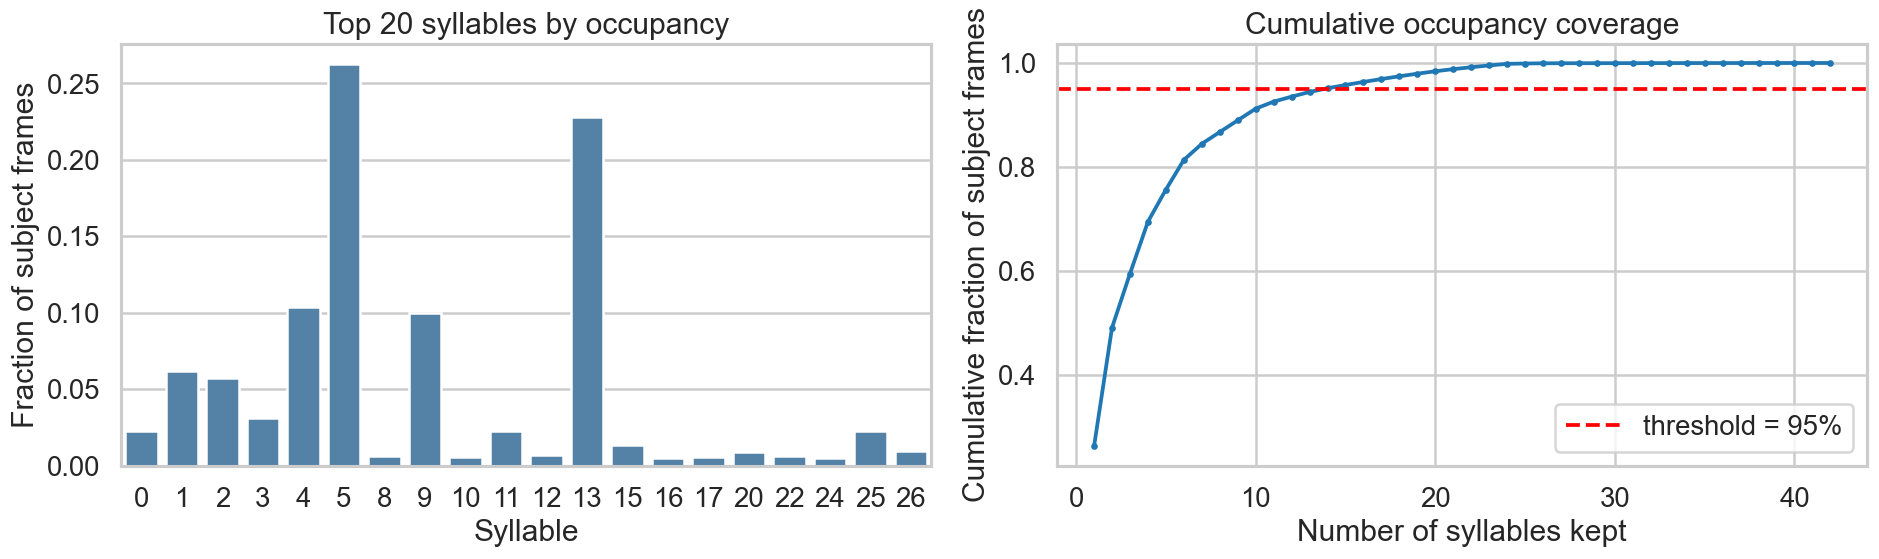

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=occupancy.head(20), x="syllable", y="prop", color="steelblue", ax=axes[0])
axes[0].set_title("Top 20 syllables by occupancy")
axes[0].set_xlabel("Syllable")
axes[0].set_ylabel("Fraction of subject frames")

axes[1].plot(np.arange(1, len(occupancy) + 1), occupancy["cum_prop"], marker="o", ms=3)
axes[1].axhline(cumulative_threshold, color="red", linestyle="--", label=f"threshold = {cumulative_threshold:.0%}")
axes[1].set_title("Cumulative occupancy coverage")
axes[1].set_xlabel("Number of syllables kept")
axes[1].set_ylabel("Cumulative fraction of subject frames")
axes[1].legend()

plt.tight_layout()

## Keep Top Syllables Covering the Threshold

In [123]:
kept_syllables = select_kept_syllables(occupancy, threshold=cumulative_threshold)
kept_syllables

[5, 13, 4, 9, 1, 2, 3, 0, 25, 11, 15, 26, 20, 12]

In [124]:
occupancy["kept"] = occupancy["syllable"].isin(kept_syllables)
occupancy[occupancy["kept"]].tail()

,syllable,n_frames,prop,cum_prop,kept
9,11,8469,0.022432,0.912122,True
10,15,5109,0.013532,0.925655,True
11,26,3617,0.009581,0.935235,True
12,20,3396,0.008995,0.944230,True
13,12,2711,0.007181,0.951411,True


In [125]:
occupancy

,syllable,n_frames,prop,cum_prop,kept
0,5,99230,0.262836,0.262836,True
1,13,86123,0.228119,0.490955,True
2,4,39201,0.103834,0.594788,True
3,9,37726,0.099927,0.694715,True
4,1,23315,0.061756,0.756471,True
5,2,21577,0.057152,0.813623,True
6,3,11652,0.030863,0.844486,True
7,0,8583,0.022734,0.867221,True
8,25,8483,0.022469,0.889690,True
9,11,8469,0.022432,0.912122,True


## First Pass: Top Syllables + Other

## Optional: Map Rare Syllables to the Most Similar Kept Syllable

Similarity here is based on the transition profile of each syllable.
You can inspect the mapping table before deciding whether to use it.

In [126]:
mapping, mapping_table = map_rare_to_kept_by_similarity(df, kept_syllables, syllable_col="syllable")
mapping_table.head(25)

,rare_syllable,mapped_to,similarity
0,8,0,0.567868
2,14,0,0.474071
12,35,0,0.400636
15,39,0,0.226143
16,43,0,0.176945
14,38,0,0.136179
5,18,0,0.124192
6,19,0,0.094311
25,54,0,0.090983
24,53,0,0.087470


In [127]:
if not apply_grouping:
    df_grouped = df.copy()
    df_grouped["syllable_grouped"] = df_grouped["syllable"]
elif use_similarity_mapping:
    df_grouped = apply_similarity_mapping(df, kept_syllables, mapping, source_col="syllable", out_col="syllable_grouped")
else:
    df_grouped = add_other_group(df, kept_syllables, source_col="syllable", out_col="syllable_grouped")

final_grouped_occupancy = compute_occupancy_table(df_grouped, syllable_col="syllable_grouped")
final_grouped_occupancy.head(20)

,syllable_grouped,n_frames,prop,cum_prop
0,5,99230,0.262836,0.262836
1,13,86123,0.228119,0.490955
2,4,39201,0.103834,0.594788
3,9,37726,0.099927,0.694715
4,1,23315,0.061756,0.756471
5,2,21577,0.057152,0.813623
6,3,11652,0.030863,0.844486
7,0,8583,0.022734,0.867221
8,25,8483,0.022469,0.889690
9,11,8469,0.022432,0.912122


## Transition Analysis on Grouped Syllables

In [128]:
transitions_grouped = extract_transitions(df_grouped, syllable_col="syllable_grouped")
transition_matrix_grouped = build_transition_matrix(transitions_grouped, from_col="from_state", to_col="to_state", normalize=True)
analysis_label = "Grouped syllable" if apply_grouping else "Syllable"
transition_matrix_grouped

to_state,0,1,2,3,4,5,8,9,10,11,...,46,48,49,50,51,52,53,54,55,56
from_state,,,,,,,,,,,,,,,,,,,,,
0,0.592217,0.209251,0.063614,0.002447,0.009204,0.005942,0.032739,0.005942,0.008622,0.023302,...,0.000000,0.000000,0.000117,0.000117,0.000000,0.000000,0.000233,0.000117,0.000000,0.000000
1,0.037018,0.827264,0.011839,0.001544,0.005147,0.009952,0.019388,0.003818,0.012182,0.004332,...,0.000043,0.000129,0.000086,0.000043,0.000129,0.000257,0.000000,0.000000,0.000000,0.000000
2,0.007045,0.002827,0.899889,0.013255,0.023684,0.037356,0.002781,0.004125,0.000093,0.000973,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000046,0.000000,0.000000,0.000000
3,0.005579,0.006609,0.033044,0.908677,0.001888,0.022659,0.001717,0.000000,0.002832,0.002489,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000086,0.000000
4,0.003418,0.001658,0.005638,0.003725,0.942448,0.033470,0.001505,0.001250,0.000204,0.000893,...,0.000000,0.000000,0.000000,0.000000,0.000026,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.001209,0.001179,0.003376,0.005049,0.012790,0.957620,0.000312,0.008738,0.000060,0.002086,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000010,0.000000,0.000000,0.000000,0.000000
8,0.355961,0.109461,0.000000,0.000000,0.000000,0.000000,0.448027,0.000000,0.016971,0.000849,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000424,0.000000,0.000000
9,0.001272,0.000530,0.002969,0.001431,0.001484,0.021126,0.000265,0.957032,0.000053,0.003075,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,0.127988,0.120518,0.000000,0.000000,0.000000,0.000996,0.016434,0.000498,0.683765,0.000996,...,0.000000,0.000000,0.000498,0.000000,0.000000,0.000000,0.000996,0.000000,0.000000,0.000000


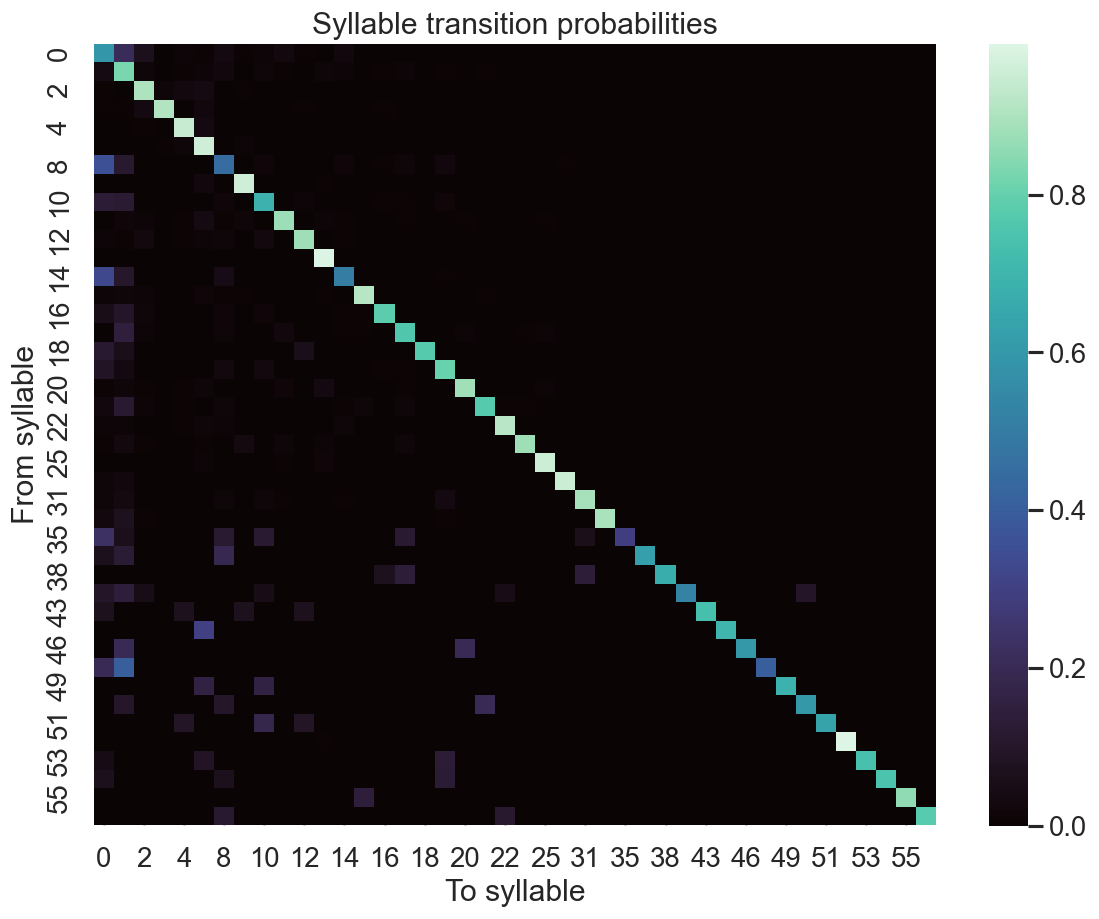

In [129]:
plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix_grouped, cmap="mako")
plt.title(f"{analysis_label} transition probabilities")
plt.xlabel(f"To {analysis_label.lower()}")
plt.ylabel(f"From {analysis_label.lower()}")
plt.tight_layout()

## Bout Analysis on Grouped Syllables

In [130]:
df_grouped_bouts = add_bout_and_investigation_labels(df_grouped, behavior_csv_dir, BOUT_DEFINITIONS, grouped_col="syllable_grouped")
df_grouped_bouts.head()

,recording_name,frame_index,syllable,time_s,centroid_x,centroid_y,heading,subject_name,trial_name,track_name,...,n_frames,fps,bout_name,bout_start_s,bout_end_s,syllable_grouped,bout_label,bout_type,bout_phase,in_investigation
0,n5_subject,0,1,0.0,479.999302,179.382026,3.060036,n5,n5-240823-085032,subject,...,15058,10.0,NaN,NaN,NaN,1,<NA>,<NA>,<NA>,False
1,n5_subject,1,1,0.1,478.388671,185.510468,2.640279,n5,n5-240823-085032,subject,...,15058,10.0,NaN,NaN,NaN,1,<NA>,<NA>,<NA>,False
2,n5_subject,2,1,0.2,482.615886,178.666205,2.967980,n5,n5-240823-085032,subject,...,15058,10.0,NaN,NaN,NaN,1,<NA>,<NA>,<NA>,False
3,n5_subject,3,1,0.3,483.243912,178.498985,2.961226,n5,n5-240823-085032,subject,...,15058,10.0,NaN,NaN,NaN,1,<NA>,<NA>,<NA>,False
4,n5_subject,4,1,0.4,482.484321,177.155721,2.979535,n5,n5-240823-085032,subject,...,15058,10.0,NaN,NaN,NaN,1,<NA>,<NA>,<NA>,False


,segment_id,syllable_grouped,start_s,end_s,n_frames,in_investigation,duration_s,state_code
0,1,1,0.0,0.5,6,False,0.6,4
1,2,9,0.6,2.1,16,False,1.6,2
2,3,5,2.2,3.3,12,False,1.2,0
3,4,3,3.4,3.5,2,False,0.2,6
4,5,1,3.6,5.2,17,False,1.7,4


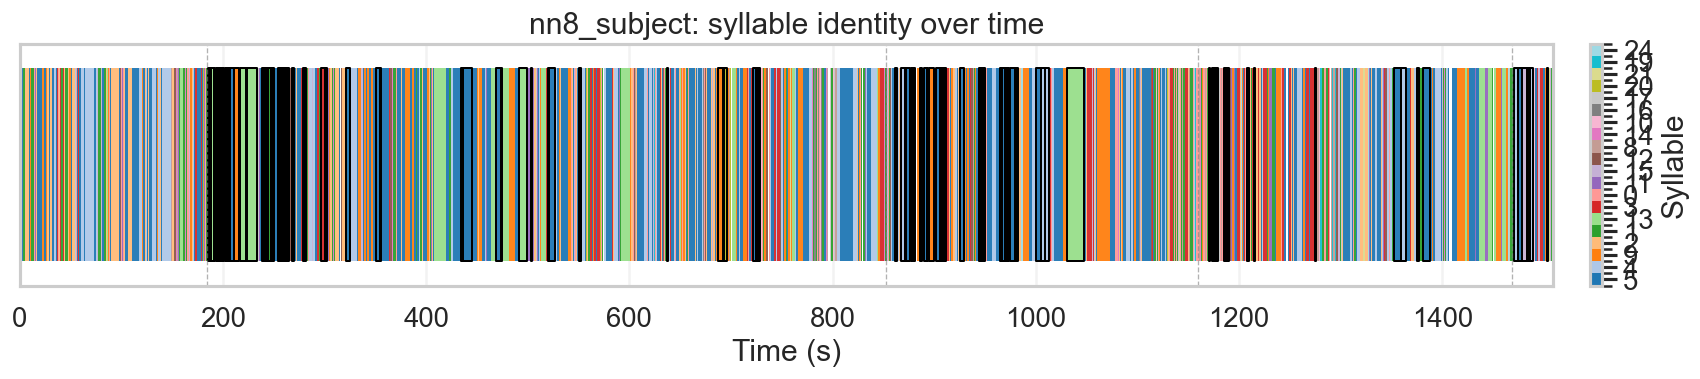

In [131]:
# Example syllable timeline for one mouse.
# This shows state identity as a single-row colored strip spanning the full duration of each syllable bout.
from matplotlib.colors import BoundaryNorm, ListedColormap

example_recording_name = sorted(df_grouped_bouts["recording_name"].unique())[10]
timeline_start_s = None  # set a number like 0 or 60 to zoom in
timeline_end_s = None    # set a number like 120 to zoom in
time_windows = None      # optional list like [(0, 60), (120, 180)] to show only selected intervals
max_states_to_label = 20  # if there are many syllables, keep the most frequent ones visible

timeline_df = (
    df_grouped_bouts[df_grouped_bouts["recording_name"] == example_recording_name]
    .sort_values(["frame_index", "time_s"])
    .reset_index(drop=True)
    .copy()
)

if time_windows is None:
    if timeline_start_s is not None:
        timeline_df = timeline_df[timeline_df["time_s"] >= timeline_start_s].copy()
    if timeline_end_s is not None:
        timeline_df = timeline_df[timeline_df["time_s"] <= timeline_end_s].copy()
else:
    window_mask = pd.Series(False, index=timeline_df.index)
    for start_s, end_s in time_windows:
        window_mask = window_mask | timeline_df["time_s"].between(start_s, end_s)
    timeline_df = timeline_df[window_mask].copy()

state_counts = timeline_df["syllable_grouped"].value_counts()
states_to_plot = list(state_counts.head(max_states_to_label).index)
timeline_df = timeline_df[timeline_df["syllable_grouped"].isin(states_to_plot)].copy()

state_order = list(state_counts.loc[states_to_plot].sort_values(ascending=False).index)
state_to_code = {state: idx for idx, state in enumerate(state_order)}

timeline_df["state_changed"] = (
    (timeline_df["syllable_grouped"] != timeline_df["syllable_grouped"].shift())
    | ((timeline_df["frame_index"] - timeline_df["frame_index"].shift()) != 1)
)
timeline_df["segment_id"] = timeline_df["state_changed"].cumsum()

segments = (
    timeline_df.groupby(["segment_id", "syllable_grouped"], as_index=False)
    .agg(
        start_s=("time_s", "min"),
        end_s=("time_s", "max"),
        n_frames=("frame_index", "size"),
        in_investigation=("in_investigation", "max"),
    )
)

fps_guess = float(timeline_df["fps"].iloc[0]) if "fps" in timeline_df.columns and len(timeline_df) else 10.0
frame_dt = 1.0 / fps_guess if fps_guess > 0 else 0.1
segments["duration_s"] = (segments["end_s"] - segments["start_s"]) + frame_dt

if time_windows is not None:
    clipped_parts = []
    for start_s, end_s in time_windows:
        part = segments[(segments["end_s"] >= start_s) & (segments["start_s"] <= end_s)].copy()
        if len(part) == 0:
            continue
        part["start_s"] = part["start_s"].clip(lower=start_s)
        part["end_s"] = part["end_s"].clip(upper=end_s)
        part["duration_s"] = (part["end_s"] - part["start_s"]) + frame_dt
        clipped_parts.append(part)
    segments = pd.concat(clipped_parts, ignore_index=True) if clipped_parts else segments.iloc[0:0].copy()

segments["state_code"] = segments["syllable_grouped"].map(state_to_code)

palette = sns.color_palette("tab20", n_colors=len(state_order))
state_to_color = {state: palette[idx % len(palette)] for idx, state in enumerate(state_order)}
cmap = ListedColormap([state_to_color[state] for state in state_order])
norm = BoundaryNorm(np.arange(len(state_order) + 1) - 0.5, cmap.N)

fig, ax = plt.subplots(figsize=(16, 3.5))
for _, row in segments.iterrows():
    ax.broken_barh(
        [(row["start_s"], row["duration_s"])],
        (0.1, 0.8),
        facecolors=state_to_color[row["syllable_grouped"]],
        edgecolors="none",
        alpha=0.95,
    )

investigation_segments = segments[segments["in_investigation"]].copy()
for _, row in investigation_segments.iterrows():
    ax.broken_barh(
        [(row["start_s"], row["duration_s"])],
        (0.1, 0.8),
        facecolors="none",
        edgecolors="black",
        linewidth=1.2,
    )

ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_ylabel("")
ax.set_title(f"{example_recording_name}: {analysis_label.lower()} identity over time")
ax.set_ylim(0, 1)
ax.grid(axis="x", alpha=0.25)

for bout_label, bout_df in timeline_df.dropna(subset=["bout_phase"]).groupby("bout_phase"):
    ax.axvline(bout_df["time_s"].min(), color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(analysis_label)
cbar.set_ticks(range(len(state_order)))
cbar.set_ticklabels([str(state) for state in state_order])

if len(segments):
    ax.set_xlim(segments["start_s"].min(), (segments["start_s"] + segments["duration_s"]).max())

plt.tight_layout()
segments.head()

In [132]:
bout_occupancy = (
    df_grouped_bouts.dropna(subset=["bout_phase"])
    .groupby(["subject_name", "bout_phase", "syllable_grouped"])
    .size()
    .reset_index(name="n_frames")
)

bout_occupancy["prop_within_subject_bout"] = bout_occupancy.groupby(["subject_name", "bout_phase"])["n_frames"].transform(lambda x: x / x.sum())
bout_occupancy.head(20)

,subject_name,bout_phase,syllable_grouped,n_frames,prop_within_subject_bout
0,n5,Long_Term-1,0,18,0.047493
1,n5,Long_Term-1,1,17,0.044855
2,n5,Long_Term-1,2,66,0.174142
3,n5,Long_Term-1,3,40,0.105541
4,n5,Long_Term-1,4,140,0.369393
5,n5,Long_Term-1,5,56,0.147757
6,n5,Long_Term-1,8,5,0.013193
7,n5,Long_Term-1,9,6,0.015831
8,n5,Long_Term-1,11,8,0.021108
9,n5,Long_Term-1,12,4,0.010554


c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

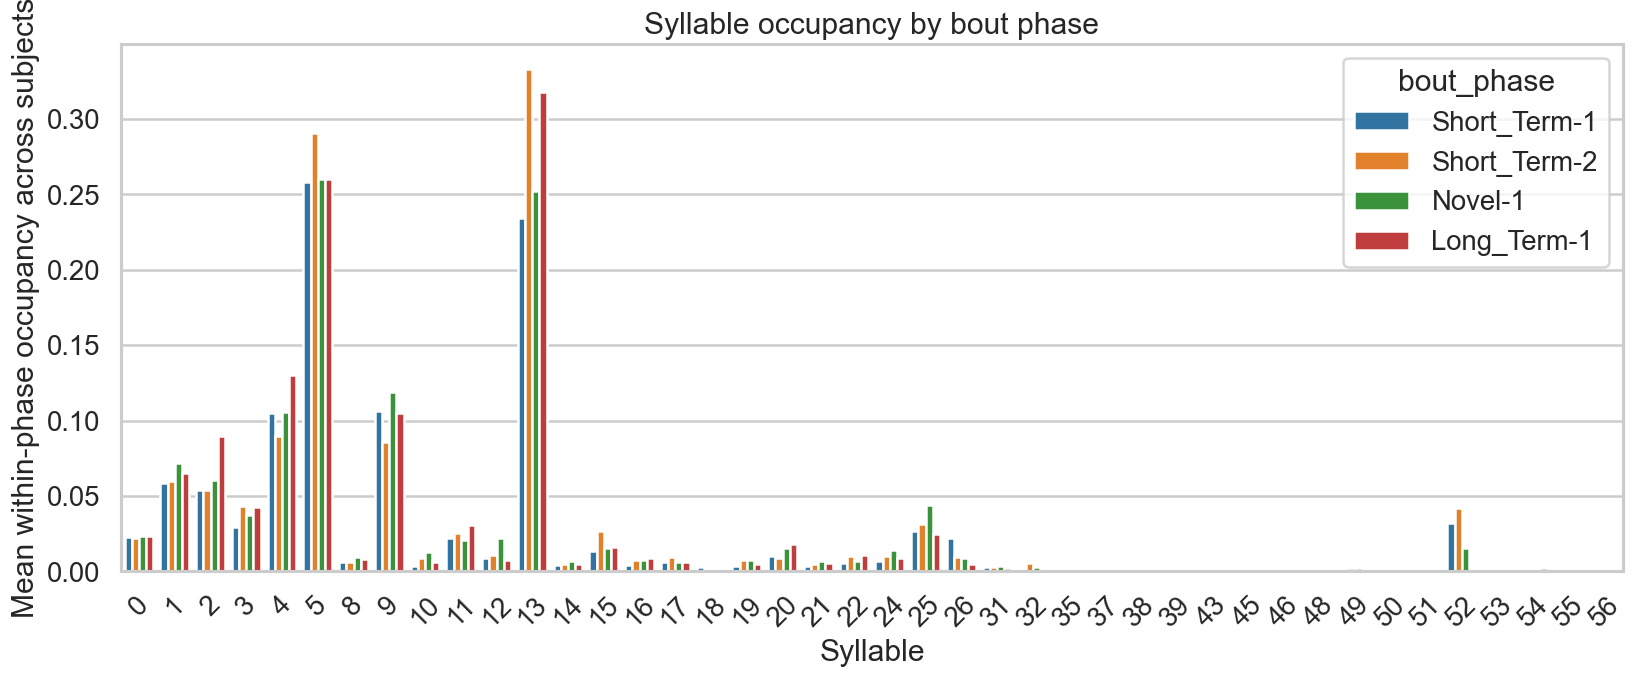

In [133]:
bout_phase_order = ["Short_Term-1", "Short_Term-2", "Novel-1", "Long_Term-1"]

bout_summary = (
    bout_occupancy.groupby(["bout_phase", "syllable_grouped"])["prop_within_subject_bout"]
    .mean()
    .reset_index()
)
bout_summary["bout_phase"] = pd.Categorical(bout_summary["bout_phase"], categories=bout_phase_order, ordered=True)
bout_summary = bout_summary.sort_values(["bout_phase", "syllable_grouped"])

plt.figure(figsize=(14, 6))
sns.barplot(data=bout_summary, x="syllable_grouped", y="prop_within_subject_bout", hue="bout_phase")
plt.title(f"{analysis_label} occupancy by bout phase")
plt.xlabel(analysis_label)
plt.ylabel("Mean within-phase occupancy across subjects")
plt.xticks(rotation=45)
plt.tight_layout()

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

,bout_phase,syllable_grouped,prop_within_subject_bout
83,Short_Term-1,0,0.023061
84,Short_Term-1,1,0.058409
85,Short_Term-1,2,0.053971
86,Short_Term-1,3,0.029293
87,Short_Term-1,4,0.104976
...,...,...,...
40,NaN,15,0.006627
44,NaN,20,0.006627
46,NaN,22,0.007290
47,NaN,24,0.004970


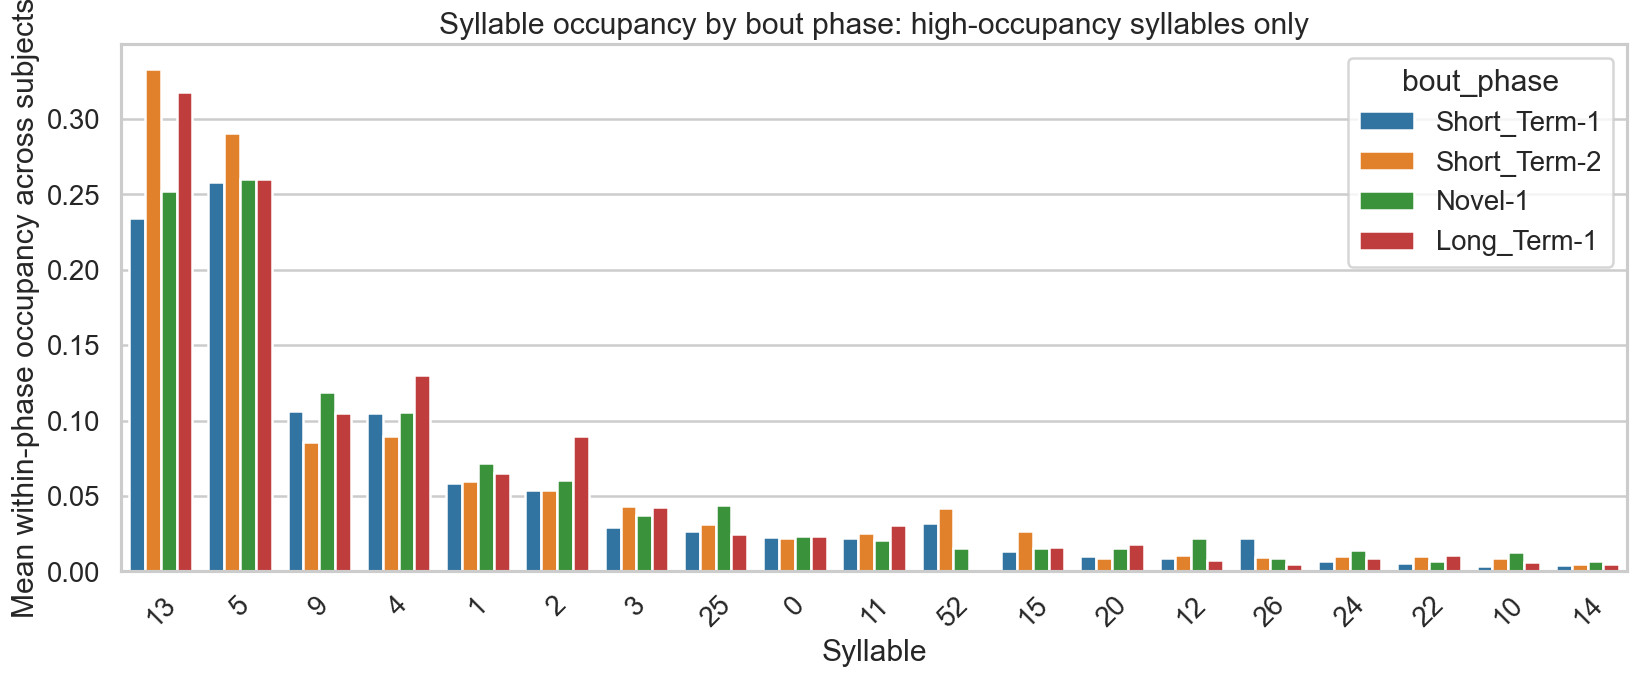

In [134]:
# Keep only syllables with substantial total occupancy across all bout phases.
# Adjust one of these thresholds depending on how aggressive you want the filter to be.
min_mean_prop = 0.01  # keep syllables with at least 1% mean occupancy in any bout phase
top_n_syllables = None  # or set an integer like 10 to keep only the top N syllables overall

syllable_totals = (
    bout_summary.groupby("syllable_grouped")["prop_within_subject_bout"]
    .sum()
    .sort_values(ascending=False)
)

syllables_above_threshold = set(
    bout_summary.loc[
        bout_summary["prop_within_subject_bout"] >= min_mean_prop,
        "syllable_grouped",
    ]
)

if top_n_syllables is not None:
    syllables_to_plot = list(syllable_totals.head(top_n_syllables).index)
else:
    syllables_to_plot = [
        syllable for syllable in syllable_totals.index if syllable in syllables_above_threshold
    ]

bout_summary_filtered = bout_summary[
    bout_summary["syllable_grouped"].isin(syllables_to_plot)
].copy()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=bout_summary_filtered,
    x="syllable_grouped",
    y="prop_within_subject_bout",
    hue="bout_phase",
    order=syllables_to_plot,
)
plt.title(f"{analysis_label} occupancy by bout phase: high-occupancy syllables only")
plt.xlabel(analysis_label)
plt.ylabel("Mean within-phase occupancy across subjects")
plt.xticks(rotation=45)
plt.tight_layout()

bout_summary_filtered

## Investigation-Only Grouped Analysis

In [135]:
investigation_df = df_grouped_bouts[df_grouped_bouts["in_investigation"]].copy()
investigation_occ = compute_occupancy_table(investigation_df, syllable_col="syllable_grouped")
investigation_occ.head(20)

,syllable_grouped,n_frames,prop,cum_prop
0,5,9429,0.285563,0.285563
1,13,6012,0.182077,0.467640
2,9,3483,0.105485,0.573125
3,4,3100,0.093885,0.667010
4,1,2143,0.064902,0.731912
5,2,2030,0.061480,0.793392
6,3,1062,0.032163,0.825555
7,11,949,0.028741,0.854296
8,0,848,0.025682,0.879978
9,25,760,0.023017,0.902995


c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


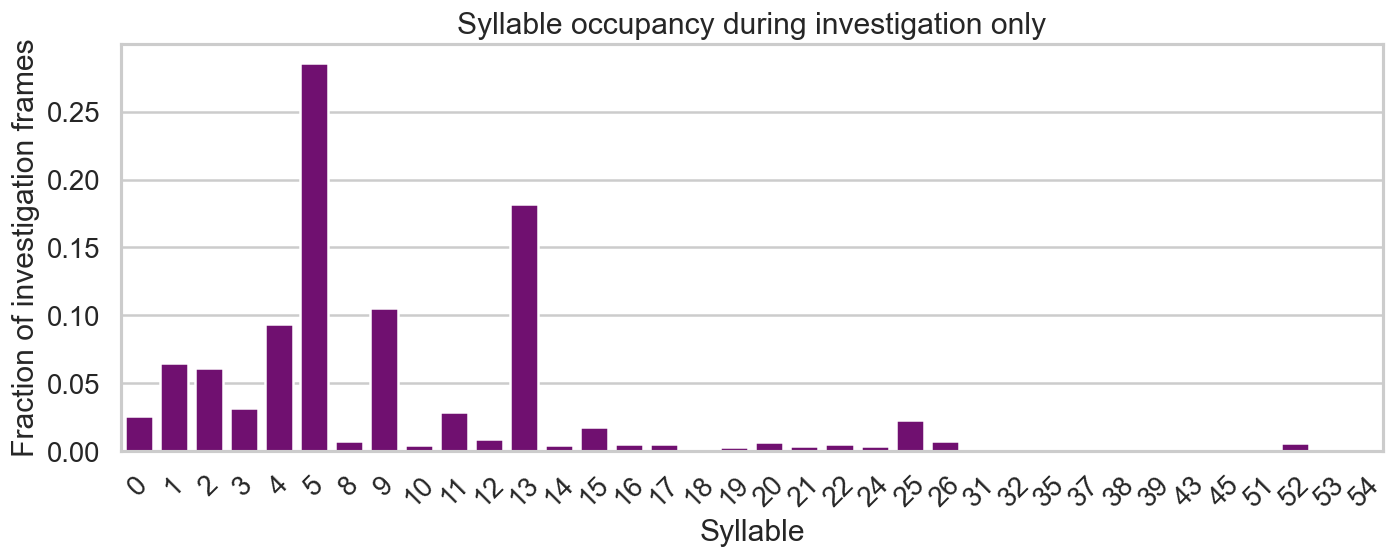

In [136]:
plt.figure(figsize=(12, 5))
sns.barplot(data=investigation_occ, x="syllable_grouped", y="prop", color="purple")
plt.title(f"{analysis_label} occupancy during investigation only")
plt.xlabel(analysis_label)
plt.ylabel("Fraction of investigation frames")
plt.xticks(rotation=45)
plt.tight_layout()

## Social-Only Analysis

In [137]:
valid_bout_phases = ["Short_Term-1", "Short_Term-2", "Novel-1", "Long_Term-1"]

da_social_df = load_da_social_frame(da_path, valid_bout_phases)

df_grouped_bouts_social = df_grouped_bouts.copy()
df_grouped_bouts_social["brain_region"] = df_grouped_bouts_social["subject_name"].map(infer_region_from_subject)
df_grouped_bouts_social = add_social_context_to_frames(df_grouped_bouts_social, da_social_df)

social_df = df_grouped_bouts_social[df_grouped_bouts_social["social_proximity"]].copy()
social_occ = compute_occupancy_table(social_df, syllable_col="syllable_grouped")
social_occ.head(20)

,syllable_grouped,n_frames,prop,cum_prop
0,5,19060,0.275286,0.275286
1,13,14341,0.207129,0.482415
2,9,7299,0.105421,0.587836
3,4,6807,0.098314,0.686150
4,2,4365,0.063044,0.749195
5,1,4112,0.059390,0.808585
6,3,2431,0.035111,0.843696
7,11,1714,0.024756,0.868452
8,0,1704,0.024611,0.893063
9,25,1687,0.024366,0.917429


c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


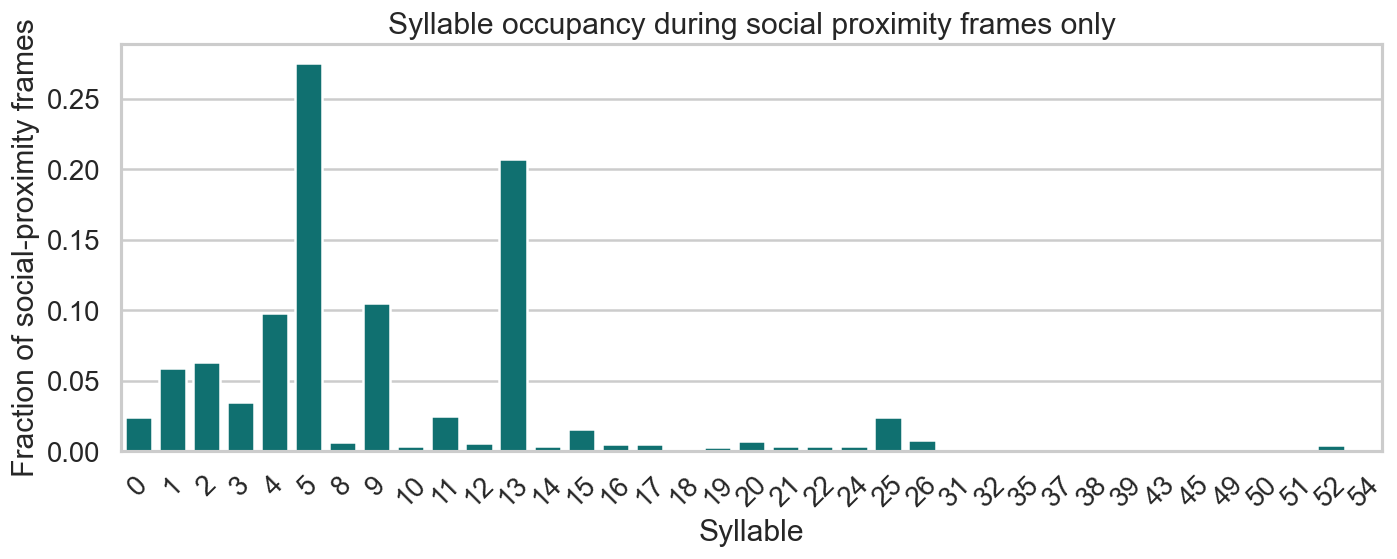

In [138]:
plt.figure(figsize=(12, 5))
sns.barplot(data=social_occ, x="syllable_grouped", y="prop", color="teal")
plt.title(f"{analysis_label} occupancy during social proximity frames only")
plt.xlabel(analysis_label)
plt.ylabel("Fraction of social-proximity frames")
plt.xticks(rotation=45)
plt.tight_layout()

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

,bout_phase,syllable_grouped,mean_prop,sem_prop,n_subjects
54,Short_Term-1,0,0.022123,0.003320,25
55,Short_Term-1,1,0.051155,0.004619,25
56,Short_Term-1,2,0.053039,0.013173,24
57,Short_Term-1,3,0.029499,0.006008,23
58,Short_Term-1,4,0.103142,0.014171,25
...,...,...,...,...,...
13,Long_Term-1,15,0.026257,0.007628,11
17,Long_Term-1,20,0.024955,0.005944,7
20,Long_Term-1,24,0.011717,0.002376,9
21,Long_Term-1,25,0.055397,0.015893,10


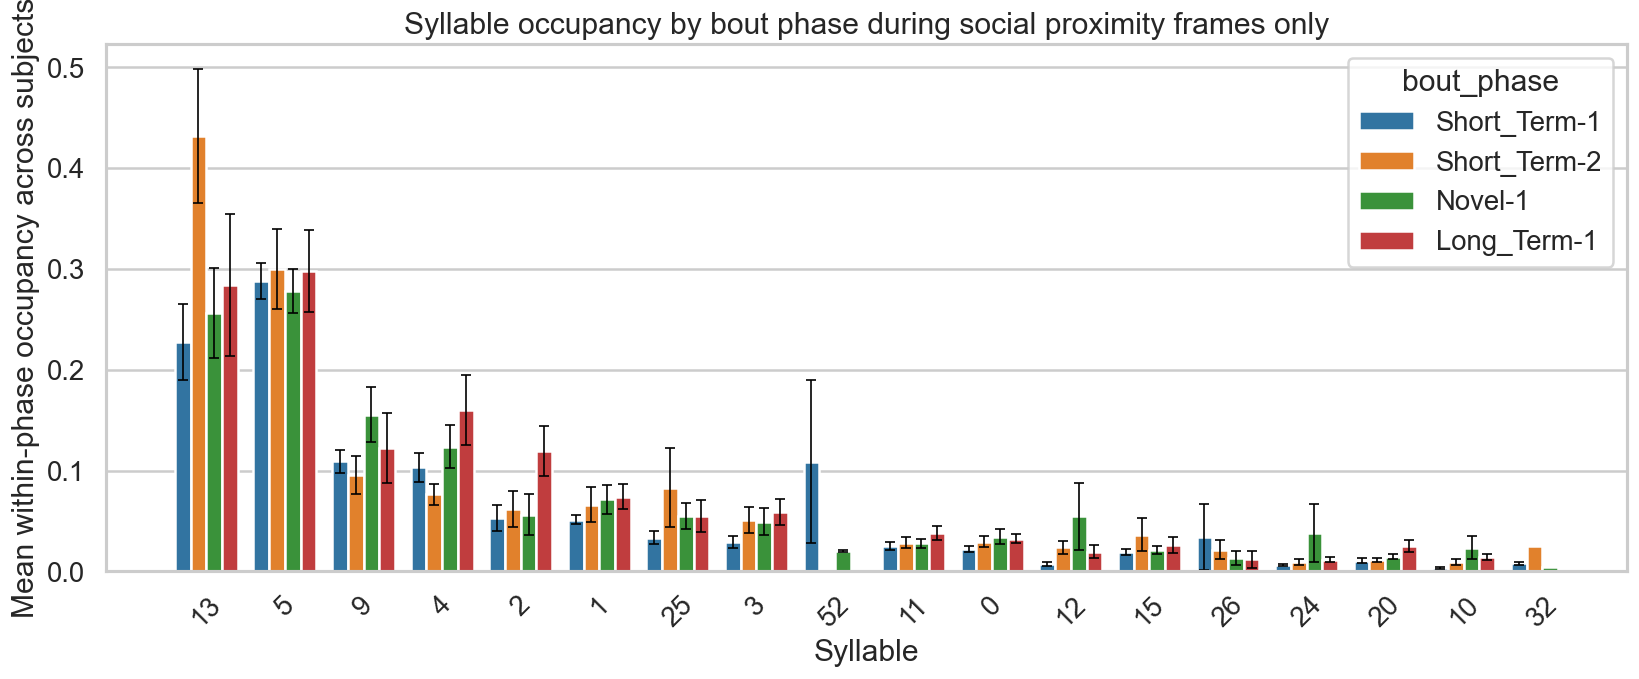

In [139]:
social_bout_occupancy = (
    social_df.dropna(subset=['bout_phase'])
    .groupby(['subject_name', 'bout_phase', 'syllable_grouped'])
    .size()
    .reset_index(name='n_frames')
)

social_bout_occupancy['prop_within_subject_bout'] = social_bout_occupancy.groupby(['subject_name', 'bout_phase'])['n_frames'].transform(
    lambda x: x / x.sum()
)

social_bout_phase_order = ['Short_Term-1', 'Short_Term-2', 'Novel-1', 'Long_Term-1']

social_bout_summary = (
    social_bout_occupancy
    .groupby(['bout_phase', 'syllable_grouped'])['prop_within_subject_bout']
    .agg(mean_prop='mean', sem_prop='sem', n_subjects='count')
    .reset_index()
)

social_bout_summary['bout_phase'] = pd.Categorical(
    social_bout_summary['bout_phase'],
    categories=social_bout_phase_order,
    ordered=True,
)

social_bout_summary = social_bout_summary.sort_values(['bout_phase', 'syllable_grouped'])

# Set to 0.01 for a looser filter or 0.02 for a stricter filter.
social_min_mean_prop = 0.02
social_top_n_syllables = None

social_syllable_totals = (
    social_bout_summary.groupby('syllable_grouped')['mean_prop']
    .sum()
    .sort_values(ascending=False)
)

social_syllables_above_threshold = set(
    social_bout_summary.loc[
        social_bout_summary['mean_prop'] >= social_min_mean_prop,
        'syllable_grouped',
    ]
)

if social_top_n_syllables is not None:
    social_syllables_to_plot = list(social_syllable_totals.head(social_top_n_syllables).index)
else:
    social_syllables_to_plot = [
        syllable for syllable in social_syllable_totals.index
        if syllable in social_syllables_above_threshold
    ]

social_bout_summary_filtered = social_bout_summary[
    social_bout_summary['syllable_grouped'].isin(social_syllables_to_plot)
].copy()

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=social_bout_summary_filtered,
    x='syllable_grouped',
    y='mean_prop',
    hue='bout_phase',
    order=social_syllables_to_plot,
    hue_order=social_bout_phase_order,
    errorbar=None,
)

for container, bout_phase in zip(ax.containers, social_bout_phase_order):
    phase_df = (
        social_bout_summary_filtered[
            social_bout_summary_filtered['bout_phase'] == bout_phase
        ]
        .set_index('syllable_grouped')
        .reindex(social_syllables_to_plot)
        .dropna(subset=['mean_prop'])
    )

    for bar, (_, row) in zip(container, phase_df.iterrows()):
        if pd.isna(row['mean_prop']) or pd.isna(row['sem_prop']):
            continue

        x = bar.get_x() + bar.get_width() / 2
        y = row['mean_prop']
        yerr = row['sem_prop']

        ax.errorbar(
            x=x,
            y=y,
            yerr=yerr,
            fmt='none',
            color='black',
            capsize=3,
            linewidth=1,
        )

plt.title(f'{analysis_label} occupancy by bout phase during social proximity frames only')
plt.xlabel(analysis_label)
plt.ylabel('Mean within-phase occupancy across subjects')
plt.xticks(rotation=45)
plt.tight_layout()

social_bout_summary_filtered



c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

,bout_phase,syllable_grouped,mean_prop,sem_prop,n_subjects
54,Short_Term-1,0,0.022123,0.003320,25
55,Short_Term-1,1,0.051155,0.004619,25
56,Short_Term-1,2,0.053039,0.013173,24
57,Short_Term-1,3,0.029499,0.006008,23
58,Short_Term-1,4,0.103142,0.014171,25
...,...,...,...,...,...
13,Long_Term-1,15,0.026257,0.007628,11
17,Long_Term-1,20,0.024955,0.005944,7
20,Long_Term-1,24,0.011717,0.002376,9
21,Long_Term-1,25,0.055397,0.015893,10


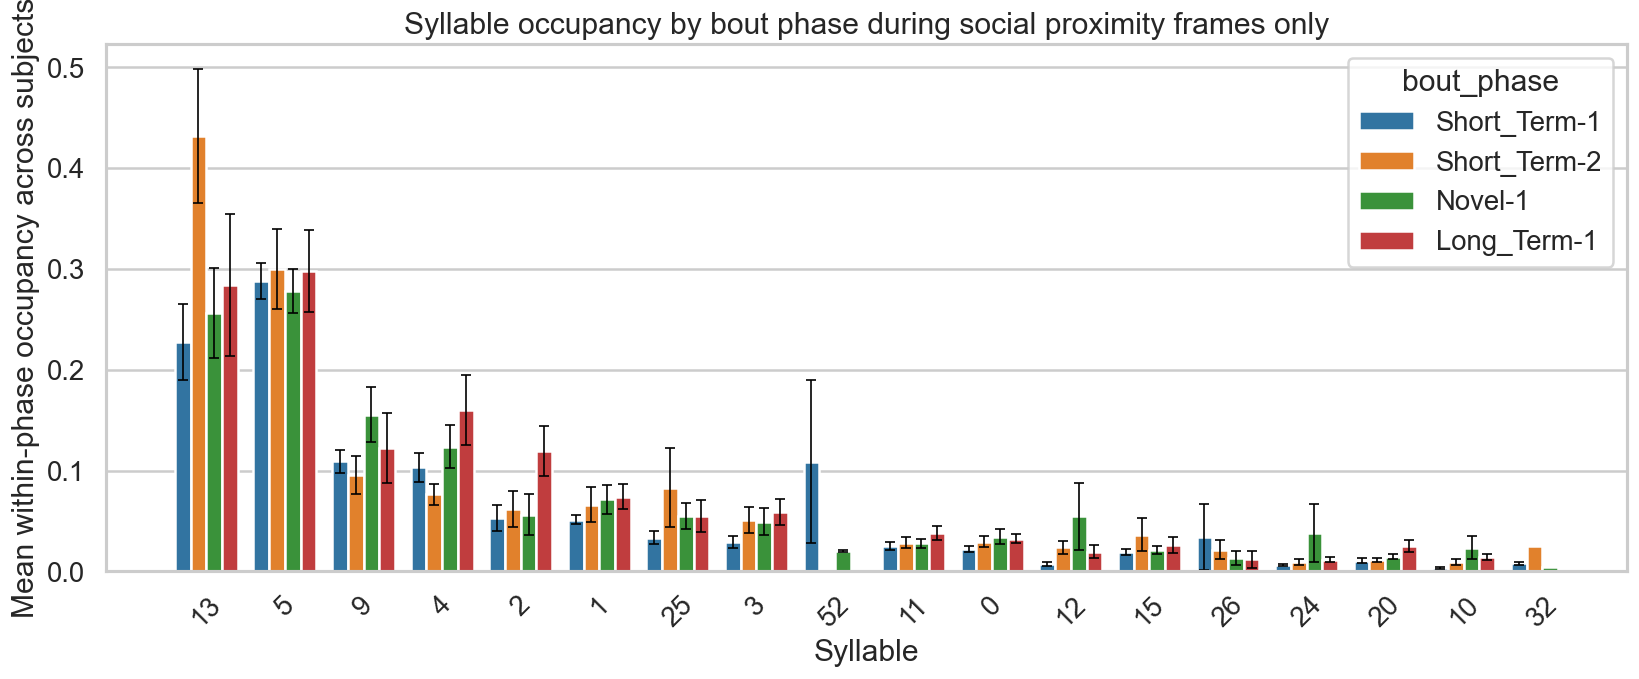

In [140]:
social_bout_occupancy = (
    social_df.dropna(subset=['bout_phase'])
    .groupby(['subject_name', 'bout_phase', 'syllable_grouped'])
    .size()
    .reset_index(name='n_frames')
)

social_bout_occupancy['prop_within_subject_bout'] = social_bout_occupancy.groupby(['subject_name', 'bout_phase'])['n_frames'].transform(
    lambda x: x / x.sum()
)

social_bout_phase_order = ['Short_Term-1', 'Short_Term-2', 'Novel-1', 'Long_Term-1']

social_bout_summary = (
    social_bout_occupancy
    .groupby(['bout_phase', 'syllable_grouped'])['prop_within_subject_bout']
    .agg(mean_prop='mean', sem_prop='sem', n_subjects='count')
    .reset_index()
)

social_bout_summary['bout_phase'] = pd.Categorical(
    social_bout_summary['bout_phase'],
    categories=social_bout_phase_order,
    ordered=True,
)

social_bout_summary = social_bout_summary.sort_values(['bout_phase', 'syllable_grouped'])

# Set to 0.01 for a looser filter or 0.02 for a stricter filter.
social_min_mean_prop = 0.02
social_top_n_syllables = None

social_syllable_totals = (
    social_bout_summary.groupby('syllable_grouped')['mean_prop']
    .sum()
    .sort_values(ascending=False)
)

social_syllables_above_threshold = set(
    social_bout_summary.loc[
        social_bout_summary['mean_prop'] >= social_min_mean_prop,
        'syllable_grouped',
    ]
)

if social_top_n_syllables is not None:
    social_syllables_to_plot = list(social_syllable_totals.head(social_top_n_syllables).index)
else:
    social_syllables_to_plot = [
        syllable for syllable in social_syllable_totals.index
        if syllable in social_syllables_above_threshold
    ]

social_bout_summary_filtered = social_bout_summary[
    social_bout_summary['syllable_grouped'].isin(social_syllables_to_plot)
].copy()

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=social_bout_summary_filtered,
    x='syllable_grouped',
    y='mean_prop',
    hue='bout_phase',
    order=social_syllables_to_plot,
    hue_order=social_bout_phase_order,
    errorbar=None,
)

for container, bout_phase in zip(ax.containers, social_bout_phase_order):
    phase_df = (
        social_bout_summary_filtered[
            social_bout_summary_filtered['bout_phase'] == bout_phase
        ]
        .set_index('syllable_grouped')
        .reindex(social_syllables_to_plot)
        .dropna(subset=['mean_prop'])
    )

    for bar, (_, row) in zip(container, phase_df.iterrows()):
        if pd.isna(row['mean_prop']) or pd.isna(row['sem_prop']):
            continue

        x = bar.get_x() + bar.get_width() / 2
        y = row['mean_prop']
        yerr = row['sem_prop']

        ax.errorbar(
            x=x,
            y=y,
            yerr=yerr,
            fmt='none',
            color='black',
            capsize=3,
            linewidth=1,
        )
        

plt.title(f'{analysis_label} occupancy by bout phase during social proximity frames only')
plt.xlabel(analysis_label)
plt.ylabel('Mean within-phase occupancy across subjects')
plt.xticks(rotation=45)
plt.tight_layout()

social_bout_summary_filtered



c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


,syllable_grouped,n_frames,prop,cum_prop
0,5,9429,0.285563,0.285563
1,13,6012,0.182077,0.467640
2,9,3483,0.105485,0.573125
3,4,3100,0.093885,0.667010
4,1,2143,0.064902,0.731912
5,2,2030,0.061480,0.793392
6,3,1062,0.032163,0.825555
7,11,949,0.028741,0.854296
8,0,848,0.025682,0.879978
9,25,760,0.023017,0.902995


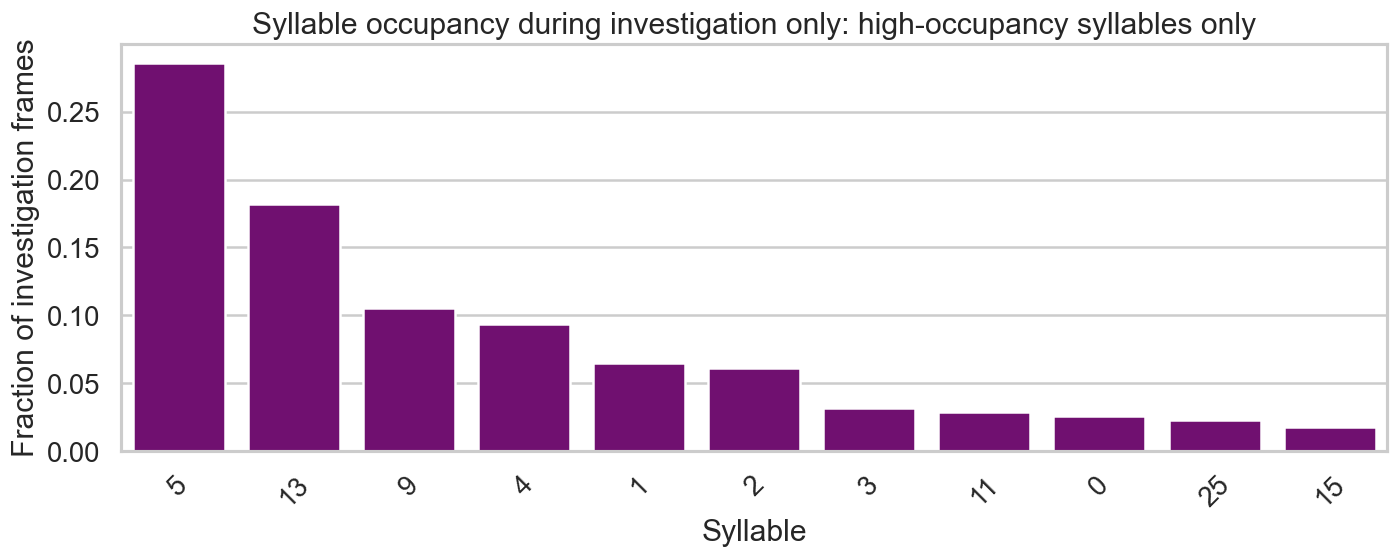

In [141]:
# Keep only syllables with substantial occupancy during investigation.
# Adjust one of these thresholds depending on how aggressive you want the filter to be.
investigation_min_prop = 0.01  # keep syllables with at least 1% of investigation frames
investigation_top_n_syllables = None  # or set an integer like 10 to keep only the top N

investigation_totals = investigation_occ.set_index("syllable_grouped")["prop"].sort_values(ascending=False)

if investigation_top_n_syllables is not None:
    investigation_syllables_to_plot = list(investigation_totals.head(investigation_top_n_syllables).index)
else:
    investigation_syllables_to_plot = list(
        investigation_occ.loc[
            investigation_occ["prop"] >= investigation_min_prop,
            "syllable_grouped",
        ]
    )

investigation_occ_filtered = investigation_occ[
    investigation_occ["syllable_grouped"].isin(investigation_syllables_to_plot)
].copy()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=investigation_occ_filtered,
    x="syllable_grouped",
    y="prop",
    color="purple",
    order=investigation_syllables_to_plot,
)
plt.title(f"{analysis_label} occupancy during investigation only: high-occupancy syllables only")
plt.xlabel(analysis_label)
plt.ylabel("Fraction of investigation frames")
plt.xticks(rotation=45)
plt.tight_layout()

investigation_occ_filtered

## Recommended Interpretation Workflow

Use this notebook in order:

1. Inspect the occupancy ranking and cumulative curve.
2. Decide whether the threshold is sensible.
3. Inspect `other_table` to see whether `other` is too heterogeneous.
4. Inspect `mapping_table` before enabling or trusting similarity mapping.
5. Compare grouped transition matrices and bout summaries.
6. Keep the original `syllable` column for all primary records, and use `syllable_grouped` only for simplified downstream analysis.
